In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_adoptions.csv")

print(df.shape)
df.head()

(173710, 97)


,adopted,is_fixed,has_name,age_in_days,outcome_year,outcome_month,outcome_weekday,is_multicolor,is_mix,animal_type_Bird,...,primary_breed_Domestic Shorthair,primary_breed_German Shepherd,primary_breed_Great Pyrenees,primary_breed_Labrador Retriever,primary_breed_Miniature Poodle,primary_breed_Other,primary_breed_Pit Bull,primary_breed_Raccoon,primary_breed_Siamese,primary_breed_Siberian Husky
0,0,0,0,365.0,2013,12,0,1,1,False,...,False,False,False,False,False,True,False,False,False,False
1,0,0,0,730.0,2014,2,5,1,0,False,...,False,False,False,False,False,False,False,True,False,False
2,0,0,0,365.0,2014,4,0,0,1,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,0,14.0,2014,6,1,1,0,True,...,False,False,False,False,False,True,False,False,False,False
4,0,0,0,14.0,2014,6,1,1,0,True,...,False,False,False,False,False,True,False,False,False,False


In [2]:
# split features (X) from target var (y)
# X: data the model will learn from (animal_type_Dog, is_fixed, has_name, age_in_days, etc)
# y: what we want the model to predict (adopted binary)

X = df.drop(columns=['adopted'])
y = df['adopted']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Adoption rate: {y.mean().round(3) * 100}%")

Features shape: (173710, 96)
Target shape: (173710,)
Adoption rate: 49.4%


In [4]:
# split data in training (80%, what the model learns from) and testing (20%, withheld data used to eval model accuracy on unseen data) sets
# random_state=42 sets a seed so the split is reproducible, same split every time it runs

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (138968, 96)
Testing set: (34742, 96)


In [6]:
# initialize and train logistic regression model

# LogisticRegression: simple but powerful model for binary classification, great starting point
# max_iter=1000: gives model enough iterations to converge on a solution
# random_state=42: makes results reproducible
# .fit(): where actual learning happens, model finds patterns in X_train that predict y_train

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model training complete")

Model training complete


/Users/helloklow/pet-adoption-predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
# model did train, but hit iteration limit before fully converging 
# two fixes: increase max_iter and scale data

from sklearn.preprocessing import StandardScaler

# scale features (brings all cols to same scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# retrain using higher max_iter
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


In [8]:
# evaluate model

# predict on test set
y_pred = model.predict(X_test_scaled)

# compare classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.73      0.79     17663
           1       0.76      0.88      0.82     17079

    accuracy                           0.80     34742
   macro avg       0.81      0.81      0.80     34742
weighted avg       0.81      0.80      0.80     34742



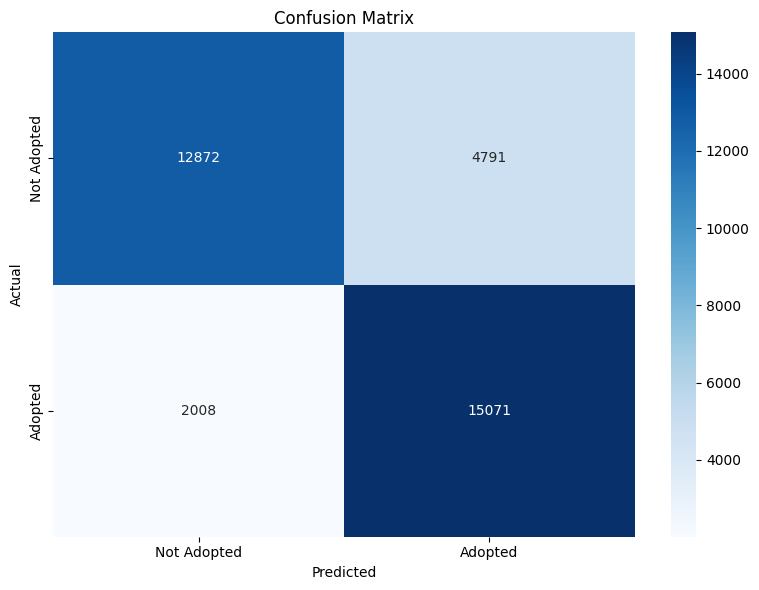

In [9]:
# visualize confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Adopted', 'Adopted'],
            yticklabels=['Not Adopted', 'Adopted'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [10]:
# 15000 true positives
# 13000 true negatives
# 4800 false positives: predicted "adopted", but not adopted; over-optimisn, flagged pet as likely to be adopted when it won't be
# 2000 false negatives: predicted "not adopted", but likely to be; pets were incorrectly written off